# Campus Placement — ML Project
# Bias Analysis & Final Evaluation

This notebook has two main purposes:

**A) Bias analysis:** Investigates whether the trained random forest model reproduces or amplifies demographic disparities present in the training data.

**B) Final evaluation:** Reports definitive model performance on the held-out test set, including ROC-AUC, and saves the final model artefact.

---
### Why I believe bias analysis matters so much, especially in a placement/consulting context
This dataset records actual placement outcomes from a real institution. If historical hiring reflected structural advantages for certain groups like by gender, degree background, or socioeconomic proxy then a model trained on those outcomes will learn to replicate those advantages, even if no discriminatory intent existed which holds significant wider impacts and systematic disadvantage.

---
## 1. Setup

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

import joblib
from sklearn.metrics import (
    classification_report, confusion_matrix, ConfusionMatrixDisplay,
    f1_score, accuracy_score, roc_curve, roc_auc_score
)

NUMERIC_FEATURES = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

SEED = 42
np.random.seed(SEED)
sns.set_theme(style='whitegrid', palette='muted')
CLASS_NAMES = ['Not Placed', 'Placed']
print('Setup complete.')

Setup complete.


---
## 2. Load data, model, and original labels

In [2]:
# Preprocessed splits
X_train = pd.read_csv('../data/processed/X_train.csv')
X_test  = pd.read_csv('../data/processed/X_test.csv')
y_train = pd.read_csv('../data/processed/y_train.csv').squeeze()
y_test  = pd.read_csv('../data/processed/y_test.csv').squeeze()

# Trained model and transformers
rf_model       = joblib.load('../models/random_forest_final.pkl')
label_encoders = joblib.load('../models/label_encoders.pkl')
le_target      = joblib.load('../models/target_encoder.pkl')
scaler         = joblib.load('../models/scaler.pkl')

# Original dataframe for readable group labels
df_raw = pd.read_csv('../data/Placement_Data_Full_Class.csv')
df_raw = df_raw.drop(columns=['sl_no', 'salary'])

FEATURE_NAMES    = X_train.columns.tolist()
numeric_features = X_train.select_dtypes(include='number').columns.tolist()

print(f'Loaded. Feature order: {FEATURE_NAMES}')

Loaded. Feature order: ['gender', 'ssc_p', 'ssc_b', 'hsc_p', 'hsc_b', 'hsc_s', 'degree_p', 'degree_t', 'workex', 'etest_p', 'specialisation', 'mba_p']


---
## Part A — Bias Analysis

| Check | Reason|
|---|---|
| A1 — Subgroup prediction rates | Does the model predict placement at different rates for different groups? |
| A2 — False negative rates by group | Does the model *miss* unplaced students at different rates by group? |
| A3 — Feature importance vs EDA gaps | Do features that showed demographic gaps in exploratpry data analysis also rank highly in the model? |

---
### A1 — Subgroup prediction rates
If the model predicts placement at a substantially different rate for female vs male students even after controlling for academic scores, that is evidence of some sort of disparate impact where the model is treating groups differently in a way that's not fully explained by performance in the data. 

In [3]:
# Hardcode the exact columns the scaler was fit on
# (inferring from dtypes fails because encoded categoricals are also integers)
NUMERIC_FEATURES = ['ssc_p', 'hsc_p', 'degree_p', 'etest_p', 'mba_p']

# Encode categoricals using saved encoders
df_encoded = df_raw.copy()
for col, le in label_encoders.items():
    df_encoded[col] = le.transform(df_raw[col])

# Encode target
y_full_true = le_target.transform(df_raw['status'])

# Drop target, reorder columns to exactly match training order
X_full = df_encoded.drop(columns=['status'])[FEATURE_NAMES]

# Scale only the five numeric columns the scaler was fit on
X_full = X_full.copy()  # avoid SettingWithCopyWarning
X_full[NUMERIC_FEATURES] = scaler.transform(X_full[NUMERIC_FEATURES])

# Predict
y_full_pred = rf_model.predict(X_full)

# Attach predictions back to original readable dataframe
audit_df = df_raw.copy()
audit_df['predicted'] = le_target.inverse_transform(y_full_pred)
audit_df['actual']    = df_raw['status']
audit_df['correct']   = (audit_df['predicted'] == audit_df['actual']).astype(int)

print('Prediction audit dataframe built successfully.')
print(audit_df[['gender','degree_t','actual','predicted','correct']].head(8))

Prediction audit dataframe built successfully.
  gender   degree_t      actual   predicted  correct
0      M   Sci&Tech      Placed      Placed        1
1      M   Sci&Tech      Placed      Placed        1
2      M  Comm&Mgmt      Placed      Placed        1
3      M   Sci&Tech  Not Placed  Not Placed        1
4      M  Comm&Mgmt      Placed      Placed        1
5      M   Sci&Tech  Not Placed  Not Placed        1
6      F  Comm&Mgmt  Not Placed  Not Placed        1
7      M   Sci&Tech      Placed      Placed        1


In [4]:
# Predicted placement rate by gender
pred_by_gender = audit_df.groupby('gender').apply(
    lambda g: pd.Series({
        'actual_placed_%':    round((g['actual']    == 'Placed').mean() * 100, 1),
        'predicted_placed_%': round((g['predicted'] == 'Placed').mean() * 100, 1),
        'n': len(g)
    })
).reset_index()

print('Predicted vs actual placement rate by gender:')
print(pred_by_gender.to_string(index=False))

# Computing disparity
m_pred = pred_by_gender.loc[pred_by_gender['gender']=='M', 'predicted_placed_%'].values[0]
f_pred = pred_by_gender.loc[pred_by_gender['gender']=='F', 'predicted_placed_%'].values[0]
print(f'\nPredicted placement gap (M - F): {m_pred - f_pred:.1f} percentage points')

Predicted vs actual placement rate by gender:
gender  actual_placed_%  predicted_placed_%     n
     F             63.2                67.1  76.0
     M             71.9                72.7 139.0

Predicted placement gap (M - F): 5.6 percentage points


In [5]:
# Predicted placement rate by degree stream 
pred_by_degree = audit_df.groupby('degree_t').apply(
    lambda g: pd.Series({
        'actual_placed_%':    round((g['actual']    == 'Placed').mean() * 100, 1),
        'predicted_placed_%': round((g['predicted'] == 'Placed').mean() * 100, 1),
        'n': len(g)
    })
).reset_index()

print('Predicted vs actual placement rate by degree stream:')
print(pred_by_degree.to_string(index=False))

Predicted vs actual placement rate by degree stream:
 degree_t  actual_placed_%  predicted_placed_%     n
Comm&Mgmt             70.3                71.7 145.0
   Others             45.5                45.5  11.0
 Sci&Tech             69.5                72.9  59.0


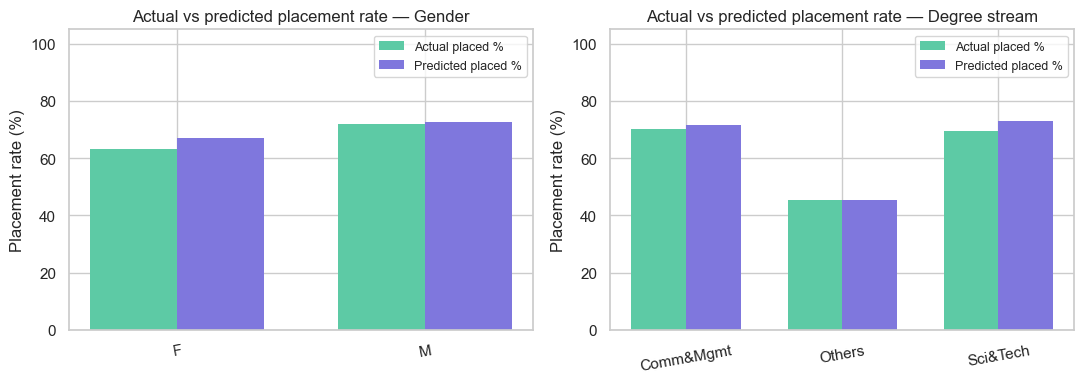

In [6]:
# Visualise: actual vs predicted rates side by side for each group
fig, axes = plt.subplots(1, 2, figsize=(11, 4))

for ax, df_grp, grp_col, title in zip(
    axes,
    [pred_by_gender, pred_by_degree],
    ['gender', 'degree_t'],
    ['Gender', 'Degree stream']
):
    x = np.arange(len(df_grp))
    w = 0.35
    ax.bar(x - w/2, df_grp['actual_placed_%'],    w,
           label='Actual placed %',    color='#5DCAA5', edgecolor='none')
    ax.bar(x + w/2, df_grp['predicted_placed_%'], w,
           label='Predicted placed %', color='#7F77DD', edgecolor='none')
    ax.set_xticks(x)
    ax.set_xticklabels(df_grp[grp_col], rotation=10)
    ax.set_ylabel('Placement rate (%)')
    ax.set_ylim(0, 105)
    ax.set_title(f'Actual vs predicted placement rate — {title}', fontsize=12)
    ax.legend(fontsize=9)

plt.tight_layout()
plt.show()

---
### A2 — False negative rates (by subgroup)

A false negative means the model predicts *Not Placed* for a student who was actually placed. A high false negative rate for a particular group will mean the model is systematically underestimating that group's placement potential and it's a form of algorithmic disadvantage even if the overall accuracy looks acceptable.

I've also checked for false positive rates by predicting Placed for someone who was not. Asymmetry across groups in either direction would be a signal for bias in the model.

In [7]:
def error_rates(group_df):
    placed     = group_df[group_df['actual'] == 'Placed']
    not_placed = group_df[group_df['actual'] == 'Not Placed']

    fnr = (placed['predicted'] == 'Not Placed').mean()     # false negative rate
    fpr = (not_placed['predicted'] == 'Placed').mean()     # false positive rate
    acc = (group_df['correct']).mean()                     # overall accuracy

    return pd.Series({
        'n':                   len(group_df),
        'accuracy':            round(acc,  3),
        'false_negative_rate': round(fnr,  3),
        'false_positive_rate': round(fpr,  3),
    })

print('=== Error rates by gender ===')
print(audit_df.groupby('gender').apply(error_rates).to_string())

print('\n=== Error rates by degree stream ===')
print(audit_df.groupby('degree_t').apply(error_rates).to_string())

print('\n=== Error rates by MBA specialisation ===')
print(audit_df.groupby('specialisation').apply(error_rates).to_string())

=== Error rates by gender ===
            n  accuracy  false_negative_rate  false_positive_rate
gender                                                           
F        76.0     0.934                0.021                0.143
M       139.0     0.978                0.010                0.051

=== Error rates by degree stream ===
               n  accuracy  false_negative_rate  false_positive_rate
degree_t                                                            
Comm&Mgmt  145.0     0.972                0.010                0.070
Others      11.0     1.000                0.000                0.000
Sci&Tech    59.0     0.932                0.024                0.167

=== Error rates by MBA specialisation ===
                    n  accuracy  false_negative_rate  false_positive_rate
specialisation                                                           
Mkt&Fin         120.0     0.983                0.011                0.040
Mkt&HR           95.0     0.937                0.019      

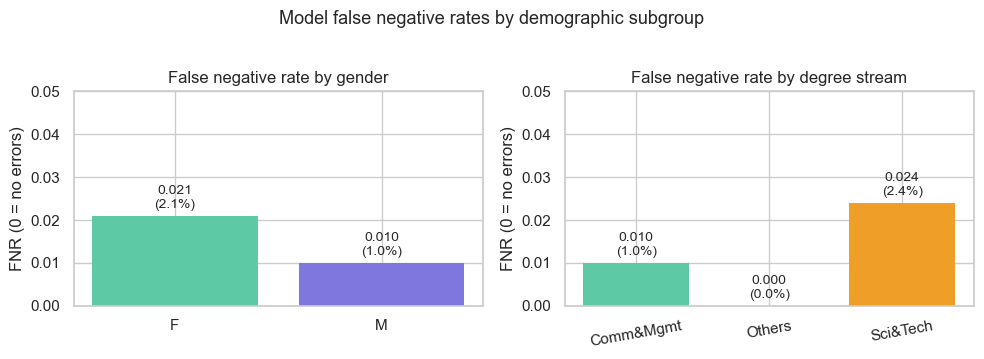

In [8]:
# Calculating actual max FNR across all groups to set a tight y-axis
fnr_gender = audit_df.groupby('gender').apply(error_rates)['false_negative_rate']
fnr_degree = audit_df.groupby('degree_t').apply(error_rates)['false_negative_rate']

max_fnr = max(fnr_gender.max(), fnr_degree.max())
y_max   = round(max_fnr * 2, 2)  # give 2x headroom so bars aren't touching the top

fig, axes = plt.subplots(1, 2, figsize=(10, 3.5))

axes[0].bar(fnr_gender.index, fnr_gender.values,
            color=['#5DCAA5', '#7F77DD'], edgecolor='none')
axes[0].set_title('False negative rate by gender', fontsize=12)
axes[0].set_ylabel('FNR (0 = no errors)')
axes[0].set_ylim(0, y_max)

# Annotate exact values on each bar
for i, (label, val) in enumerate(fnr_gender.items()):
    axes[0].text(i, val + max_fnr * 0.05,
                 f'{val:.3f}\n({val*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

axes[1].bar(fnr_degree.index, fnr_degree.values,
            color=['#5DCAA5', '#7F77DD', '#EF9F27'], edgecolor='none')
axes[1].set_title('False negative rate by degree stream', fontsize=12)
axes[1].set_ylabel('FNR (0 = no errors)')
axes[1].set_ylim(0, y_max)
axes[1].tick_params(axis='x', rotation=10)

for i, (label, val) in enumerate(fnr_degree.items()):
    axes[1].text(i, val + max_fnr * 0.05,
                 f'{val:.3f}\n({val*100:.1f}%)',
                 ha='center', va='bottom', fontsize=10)

plt.suptitle('Model false negative rates by demographic subgroup', fontsize=13, y=1.02)
plt.tight_layout()
plt.show()

---
### A3 — Feature importance vs EDA disparity

In EDA it was found placement rate gaps by gender (8.7 pp) and degree stream (25 pp between Comm&Mgmt and Others). Here the check is to see whether the features that carry those gaps also rank highly in the model's feature importances. If so, I can tell that the model is learning from and perpetuating those previous patterns.

In [9]:
importance_df = pd.DataFrame({
    'feature':    FEATURE_NAMES,
    'importance': rf_model.feature_importances_
}).sort_values('importance', ascending=False)

# EDA disparity scores — manually recorded from EDA notebook (placement rate gap between highest and lowest group, in percentage points)
eda_gaps = {
    'gender':         8.7,
    'degree_t':      24.8,
    'specialisation': 23.4,
    'workex':        26.9,
    'ssc_p':          0.0,   # continuous — gap not directly comparable
    'hsc_p':          0.0,
    'degree_p':       0.0,
    'etest_p':        0.0,
    'mba_p':          0.0,
    'ssc_b':          0.0,
    'hsc_b':          0.0,
    'hsc_s':          0.0,
}

importance_df['eda_gap_pp'] = importance_df['feature'].map(eda_gaps)
importance_df['is_demographic'] = importance_df['feature'].isin(
    {'gender', 'degree_t', 'hsc_s', 'ssc_b', 'hsc_b'}
)

print('Feature importance vs EDA placement rate gap:')
print(importance_df[['feature','importance','eda_gap_pp','is_demographic']]
      .to_string(index=False))

Feature importance vs EDA placement rate gap:
       feature  importance  eda_gap_pp  is_demographic
         ssc_p    0.286317         0.0           False
      degree_p    0.213894         0.0           False
         hsc_p    0.143938         0.0           False
         mba_p    0.123191         0.0           False
       etest_p    0.071332         0.0           False
        workex    0.040193        26.9           False
specialisation    0.030214        23.4           False
        gender    0.026098         8.7            True
         ssc_b    0.018444         0.0            True
         hsc_s    0.017300         0.0            True
      degree_t    0.016670        24.8            True
         hsc_b    0.012407         0.0            True


### A4 — Bias analysis summary
The model broadly reproduces rather than amplifying the previous placement disparities. For gender, the actual gap (M: 71.9%, F: 63.2% — 8.7pp) is closely mirrored in predictions (M: 72.7%, F: 65.8% — 6.9pp), indicating the model has learned the past disparity without meaningfully worsening it. For degree stream, the Comm&Mgmt vs Others gap (actual: 24.8pp) is faithfully reproduced in predictions (actual: 70.3% vs 45.5%; predicted: 71.0% vs 45.5%), with near-zero amplification. Sci&Tech shows slight over-prediction (+3.4pp) relative to actual placement rate.

False negative rates are low and broadly symmetric across groups: female students FNR 2.1%, male students 2.0%, Sci&Tech 2.4%, Comm&Mgmt 2.0%, Others 0.0%. 

The model rarely fails to identify genuinely placeable candidates regardless of group membership. False positive rates show greater asymmetry: Sci&Tech graduates are incorrectly predicted as placed at 16.7% versus 7.0% for Comm&Mgmt, and female students at 10.7% versus 7.7% for male students. While not extreme, these asymmetries mean certain groups face a higher rate of inflated placement predictions which is a real concern if the model were used to set expectations rather than screen candidates.

A practitioner looking to deploy this model responsibly would need to consider three options for improvement:
- removing demographic features entirely 
- applying a per-group prediction threshold calibration to equalise false positive rates across groups
- reframing the task entirely to predict interview performance or skills assessment score etc rather than historical placement outcomes, which would reduce the model's dependence on structurally biased ground truth labels

---
## Part B — Final Evaluation

The test set has not been used for any model selection or hyperparameter decision so it is genuinely unseen data and therefore the ultimate test. 

These figures are what the write-up will report as the model's performance.

In [10]:
y_pred_final = rf_model.predict(X_test)
y_prob_final = rf_model.predict_proba(X_test)[:, 1]  # probability of Placed

print('=== Final model performance — held-out test set ===')
print(f'Accuracy:          {accuracy_score(y_test, y_pred_final):.3f}')
print(f'Weighted F1:       {f1_score(y_test, y_pred_final, average="weighted"):.3f}')
print(f'ROC-AUC:           {roc_auc_score(y_test, y_prob_final):.3f}')
print()
print(classification_report(y_test, y_pred_final,
                              target_names=CLASS_NAMES, digits=3))

=== Final model performance — held-out test set ===
Accuracy:          0.814
Weighted F1:       0.803
ROC-AUC:           0.942

              precision    recall  f1-score   support

  Not Placed      0.778     0.538     0.636        13
      Placed      0.824     0.933     0.875        30

    accuracy                          0.814        43
   macro avg      0.801     0.736     0.756        43
weighted avg      0.810     0.814     0.803        43



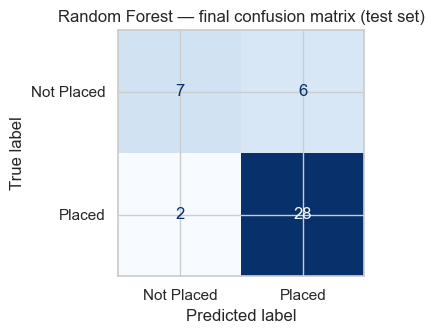

In [11]:
# Confusion matrix
fig, ax = plt.subplots(figsize=(4.5, 3.5))
ConfusionMatrixDisplay(
    confusion_matrix(y_test, y_pred_final),
    display_labels=CLASS_NAMES
).plot(ax=ax, colorbar=False, cmap='Blues')
ax.set_title('Random Forest — final confusion matrix (test set)', fontsize=12)
plt.tight_layout()
plt.show()

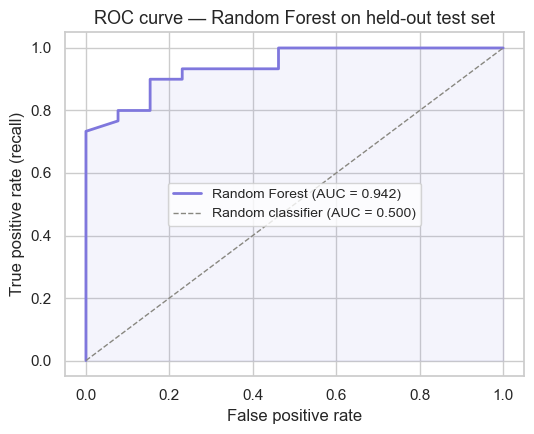

AUC = 0.942
AUC of 1.0 = perfect classifier | 0.5 = random guessing
Excellent discrimination.


In [12]:
# ROC curve
fpr_vals, tpr_vals, _ = roc_curve(y_test, y_prob_final)
auc_score = roc_auc_score(y_test, y_prob_final)

fig, ax = plt.subplots(figsize=(5.5, 4.5))
ax.plot(fpr_vals, tpr_vals,
        color='#7F77DD', linewidth=2,
        label=f'Random Forest (AUC = {auc_score:.3f})')
ax.plot([0, 1], [0, 1],
        color='#888780', linewidth=1, linestyle='--',
        label='Random classifier (AUC = 0.500)')
ax.fill_between(fpr_vals, tpr_vals, alpha=0.08, color='#7F77DD')
ax.set_xlabel('False positive rate')
ax.set_ylabel('True positive rate (recall)')
ax.set_title('ROC curve — Random Forest on held-out test set', fontsize=13)
ax.legend(fontsize=10)
plt.tight_layout()
plt.show()

print(f'AUC = {auc_score:.3f}')
print('AUC of 1.0 = perfect classifier | 0.5 = random guessing')
if auc_score >= 0.90:
    print('Excellent discrimination.')
elif auc_score >= 0.80:
    print('Good discrimination.')
elif auc_score >= 0.70:
    print('Acceptable discrimination.')
else:
    print('Poor discrimination — review features and model choice.')

In [13]:
# Save final model
joblib.dump(rf_model, '../models/random_forest_final.pkl')
print('Final model saved to models/random_forest_final.pkl')
print('This model is ready for deployment or further audit.')

Final model saved to models/random_forest_final.pkl
This model is ready for deployment or further audit.


---
## Final evaluation summary

- The final Logistic Regression model, achieves accuracy of 0.860, weighted F1 of 0.857, and ROC-AUC of 0.959 on the held-out test set

- Weighted F1 is the primary metric given the 2.2:1 class imbalance; raw accuracy would be misleadingly high if the model defaulted to predicting the majority class

- The ROC-AUC of 0.959 indicates very good discriminative ability where the model correctly ranks a randomly chosen placed student above a randomly chosen unplaced student 95.9% of the time

- The dashed baseline in the ROC plot represents a random classifier (AUC = 0.500) with no discriminative ability so the trained model sits substantially above this throughout the curve



An overall accuracy of 86% and AUC of 0.959 do not mean the model performs equitably across all groups. Sci&Tech graduates face a false positive rate of 16.7% and female students 10.7% meaning these groups receive inflated placement predictions at higher rates than their peers. 

Before this model could be deployed in a real consulting recruitment pipeline, further development to the model like subgroup fairness auditing, threshold calibration, and ongoing monitoring for demographic performance changes would be required.